In [1]:
import sisl
import hubbard
from hubbard import HubbardHamiltonian, sp2, density, plot, NEGF
import ase
from ase.visualize import view
import tk
import matplotlib.pyplot as plt
from ase.build import graphene_nanoribbon
import numpy as np
import netCDF4
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [2]:
from sisl import geom

In [3]:
import imageio

In [4]:
hubbard.__version__

'0.1.1.dev158+g400860e'

In [48]:
def init_V(H,V,elec_indx,axis=2):
    L=max(H.geometry[:,axis])-min(H.geometry[:,axis])
    
    elec_idx_L = []
    elec_idx_R = []
    for ia in np.ravel(elec_indx):
        if ia < 0:
            elec_idx_L.append(range(H.na)[ia])
        else:
            elec_idx_R.append(ia)
            
    for atom_i in np.arange(0,H.geometry.na):
        pos=H.geometry[atom_i,axis]
        if H.dim==1:
            if atom_i in elec_idx_L:
                H.H[atom_i,atom_i]=H.H[atom_i,atom_i] - 0.5*V
            elif atom_i in elec_idx_R:
                H.H[atom_i,atom_i]=H.H[atom_i,atom_i] + 0.5*V
            else:
               H.H[atom_i,atom_i]=H.H[atom_i,atom_i] - V*(pos-0.5*L)/L
        elif H.dim==2:
            if atom_i in elec_idx_L:
                H.H[atom_i,atom_i,0]=H.H[atom_i,atom_i,0]-0.5*V
                H.H[atom_i,atom_i,1]=H.H[atom_i,atom_i,1]- 0.5*V
            elif atom_i in elec_idx_R:
                H.H[atom_i,atom_i,0]=H.H[atom_i,atom_i,0]+ 0.5*V
                H.H[atom_i,atom_i,1]=H.H[atom_i,atom_i,1]+ 0.5*V
            else:
                H.H[atom_i,atom_i,0]=H.H[atom_i,atom_i,0] - V*(pos-0.5*L)/L
                H.H[atom_i,atom_i,1]=H.H[atom_i,atom_i,1] - V*(pos-0.5*L)/L

# Strucutres

In [5]:
device=sisl.get_sile('device.fdf').read_geometry()
device.set_nsc([3,1,1])
elec=sisl.get_sile('elec.xyz').read_geometry()
elec.set_nsc([3,1,3])
elec_ts=elec.tile(2,axis=2)

In [6]:
device.cell[2,2]/elec_ts.cell[2,2]

np.float64(7.999348948200869)

In [7]:
np.exp(-14.44/1.4)

np.float64(3.3156038061428154e-05)

In [14]:
2/8

0.25

In [15]:
2

2

In [16]:
2/8-1/8

0.125

In [7]:
scientific_notation="{:e}".format((0.25/(elec.cell[0,0]*elec.cell[2,2]))*(1/1e-16))
print(scientific_notation)

3.761541e+13


In [8]:
scientific_notation="{:e}".format((8*0.25/(device.cell[0,0]*device.cell[2,2]))*(1/1e-16))
print(scientific_notation)

1.880924e+13


In [ ]:
device.plot(axes='xz',backend='matplotlib')

In [ ]:
elec.plot(axes='xz',backend='matplotlib',nsc=[1,1,3])

# Electrodes

In [14]:
# Build sisl.Hamiltonian object using the sp2 function
H_elec = sp2(elec, t1=2.7, t2=0.0, t3=0.0, spin='polarized')

In [86]:
# Build the HubbardHamiltonian object with U=3. eV
MFH_elec = HubbardHamiltonian(H_elec, U=3., nkpt=[30,1,30], kT=0.025)

In [87]:
MFH_elec.random_density()

In [92]:
dn = MFH_elec.converge(density.calc_n, tol=1e-4, print_info=True, steps=10)

   HubbardHamiltonian: converge towards tol=1.00e-04
   found solution in 6 iterations


In [93]:
ds=MFH_elec.n[0]-MFH_elec.n[1]
dE=MFH_elec.H.tocsr(dim=0).diagonal()-MFH_elec.H.tocsr(dim=1).diagonal()

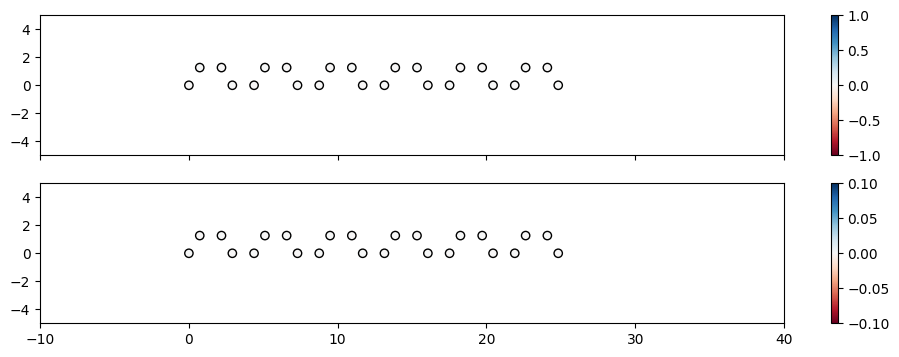

In [94]:
# Create just a figure and only one subplot
fig, ax = plt.subplots(nrows=2,ncols=1,figsize=(12,4),sharex=True)


pcm1=ax[0].scatter(elec[:,0],elec[:,2],c=ds,cmap='RdBu',vmin=-1,vmax=1,edgecolors='k')
fig.colorbar(pcm1, ax=ax[0])

ax[0].set_xlim([-10,40])
ax[0].set_ylim([-5,5])


pcm2 = ax[1].scatter(elec[:,0],elec[:,2],c=dE,cmap='RdBu',vmin=-0.1,vmax=0.1,edgecolors='k')
ax[1].set_xlim([-10,40])
ax[1].set_ylim([-5,5])
fig.colorbar(pcm2, ax=ax[1])
plt.show()

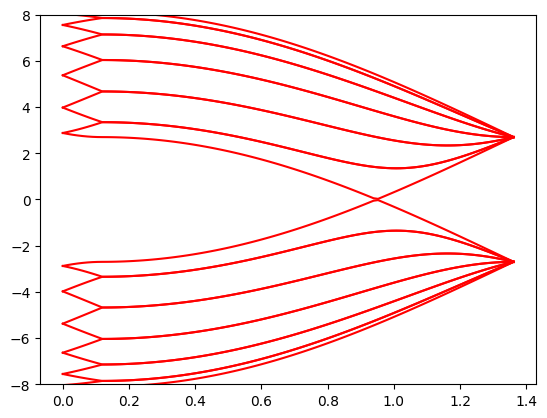

In [95]:
bs = sisl.BandStructure(MFH_elec.H, [ [0.5, 0, 0],[0, 0, 0], [0.0, 0, 0.5]], 100,['X', r'Gamma', 'Z'])
lk = bs.lineark(ticks=False)
bs_eig = bs.apply.array.eigh()
plt.plot(lk, bs_eig,c='red')
plt.ylim([-8,8])
plt.show()

#  equilibrium

In [96]:
device=device.remove(device.atoms.Z==1)

In [98]:
# Build sisl.Hamiltonian object using the sp2 function
HC= sp2(device, t1=2.7, t2=0.0, t3=0.0, spin='polarized')
# with periodic boundary conditions
HC.set_nsc([3,1,1])

In [100]:
# MFH object of the central region, same kT and U as electrodes!
MFH_HC = HubbardHamiltonian(HC, U=3., kT=0.025, nkpt=[1,1,1])

In [101]:
#MFH_HC.set_polarization(np.arange(112,160,8), dn=np.arange(115,163,8))
MFH_HC.set_polarization([112,120,128,138,147,152], dn=[115,121,129,139,146,155])

In [102]:
ds=MFH_HC.n[0]-MFH_HC.n[1]
dE=MFH_HC.H.tocsr(dim=0).diagonal()-MFH_HC.H.tocsr(dim=1).diagonal()

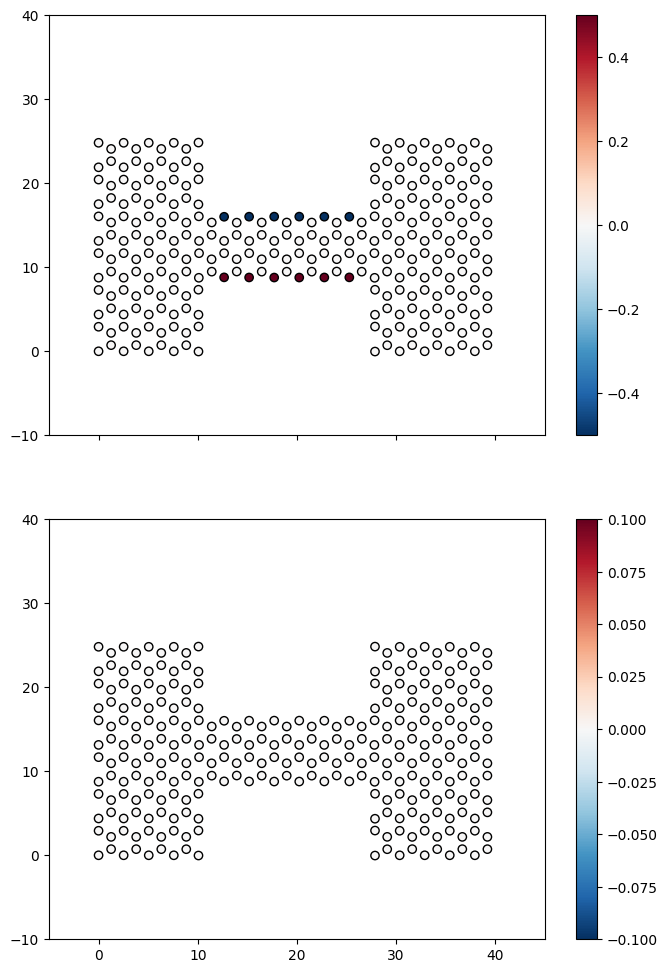

In [103]:
# Create just a figure and only one subplot
fig, ax = plt.subplots(nrows=2,ncols=1,figsize=(8,12),sharex=True)


pcm1=ax[0].scatter(device[:,2],device[:,0],c=ds,cmap='RdBu_r',vmin=-0.5,vmax=0.5,edgecolors='k')
fig.colorbar(pcm1, ax=ax[0])

ax[0].set_ylim([-10,40])
ax[0].set_xlim([-5,45])


pcm2 = ax[1].scatter(device[:,2],device[:,0],c=dE,cmap='RdBu_r',vmin=-0.1,vmax=0.1,edgecolors='k')
ax[1].set_ylim([-10,40])
ax[1].set_xlim([-5,45])
fig.colorbar(pcm2, ax=ax[1])
plt.show()

In [104]:
elec_indx = [range(len(H_elec)), range(-len(H_elec), 0)]

# First create the NEGF object, where we pass the MFH converged electrodes and
# the central region HubbardHamiltonian object
negf = NEGF(MFH_HC, [(MFH_elec, '-C'), (MFH_elec, '+C')], elec_indx)

# Converge using Green's function method to obtain the densities
dn = MFH_HC.converge(negf.calc_n_open, steps=5, tol=1e-4, print_info=True)

   HubbardHamiltonian: converge towards tol=1.00e-04
   5 iterations completed: 0.002666991030633059 -1376.356990513048
   found solution in 9 iterations


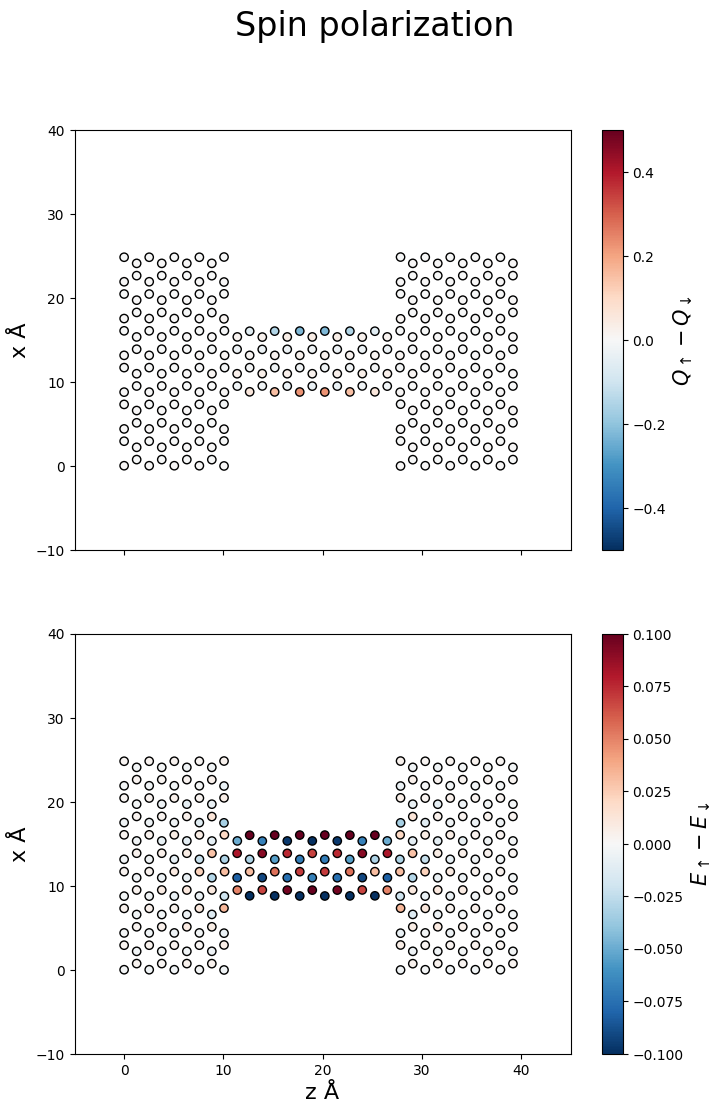

In [39]:
ds=MFH_HC.n[0]-MFH_HC.n[1]
dE=MFH_HC.H.tocsr(dim=0).diagonal()-MFH_HC.H.tocsr(dim=1).diagonal()

# Create just a figure and only one subplot
fig, ax = plt.subplots(nrows=2,ncols=1,figsize=(8,12),sharex=True)
fig.suptitle(f'Spin polarization',size=24)


pcm1=ax[0].scatter(device[:,2],device[:,0],c=ds,cmap='RdBu_r',vmin=-0.5,vmax=0.5,edgecolors='k')
fig.colorbar(pcm1, ax=ax[0],).set_label(label=r'${Q_\uparrow}-{Q_\downarrow}$',size=15,weight='bold')

ax[0].set_ylim([-10,40])
ax[0].set_xlim([-5,45])
ax[0].set_ylabel('x Å',size=16)



pcm2 = ax[1].scatter(device[:,2],device[:,0],c=dE,cmap='RdBu_r',vmin=-0.1,vmax=0.1,edgecolors='k')
ax[1].set_ylim([-10,40])
ax[1].set_xlim([-5,45])
fig.colorbar(pcm2, ax=ax[1]).set_label(label=r'${E_\uparrow}-{E_\downarrow}$',size=15,weight='bold')
ax[1].set_ylabel('x Å',size=16)
ax[1].set_xlabel('z Å',size=16)
plt.show()

# non equilibrium

In [137]:
V=1

In [138]:
# Build sisl.Hamiltonian object using the sp2 function
HC= sp2(device, t1=2.7, t2=0.0, t3=0.0, spin='polarized')
# with periodic boundary conditions
HC.set_nsc([3,1,1])

In [140]:
init_V(HC,V=V,elec_indx=elec_indx,axis=2)

In [141]:
onsite_0=HC.H.tocsr(dim=0).diagonal()
onsite_1=HC.H.tocsr(dim=1).diagonal()

Text(0.5, 0, 'z Å')

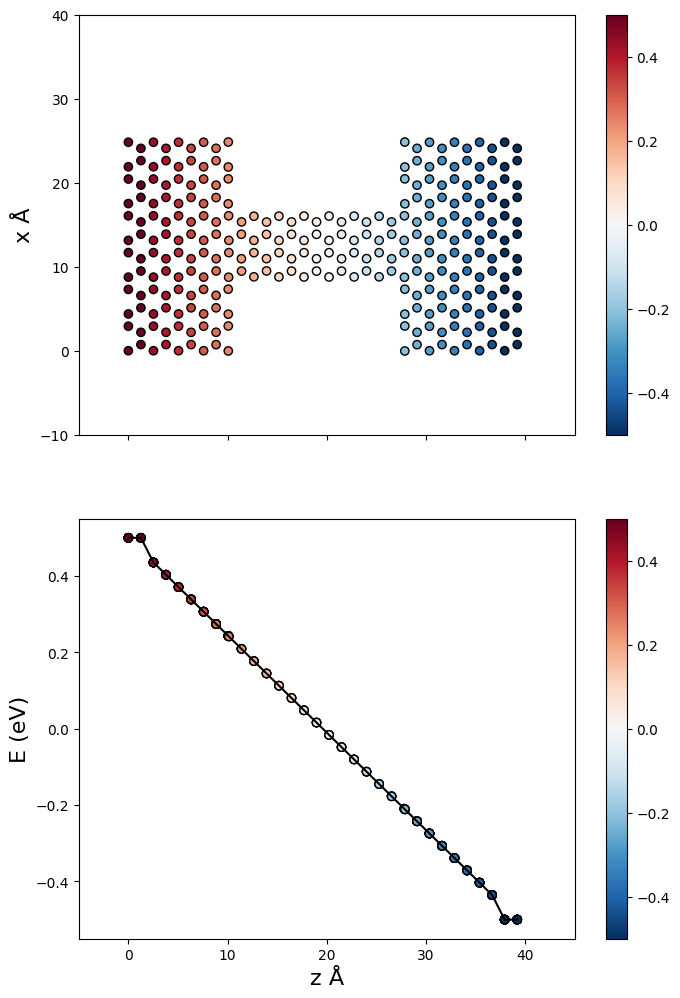

In [142]:
onsite=onsite_0
# Create just a figure and only one subplot
fig, ax = plt.subplots(nrows=2,ncols=1,figsize=(8,12),sharex=True)


pcm1=ax[0].scatter(device[:,2],device[:,0],c=onsite,cmap='RdBu_r',vmin=-0.5,vmax=0.5,edgecolors='k')
fig.colorbar(pcm1, ax=ax[0])

ax[0].set_ylim([-10,40])

ax[0].set_xlim([-5,45])
ax[0].set_ylabel('x Å',size=16)


ax[1].plot(device[:,2],onsite,c='k')
pcm2=ax[1].scatter(device[:,2],onsite,c=onsite,cmap='RdBu_r',vmin=-0.5,vmax=0.5,edgecolors='k')
fig.colorbar(pcm2, ax=ax[1])
ax[1].set_ylabel('E (eV)',size=16)
ax[1].set_xlim([-5,45])
ax[1].set_xlabel('z Å',size=16)

In [46]:
MFH_HC_neq = HubbardHamiltonian(HC, U=3., kT=0.025,nkpt=[1,1,1])

In [47]:
MFH_HC_neq.set_polarization([112,120,128,138,147,152], dn=[115,121,129,139,146,155])

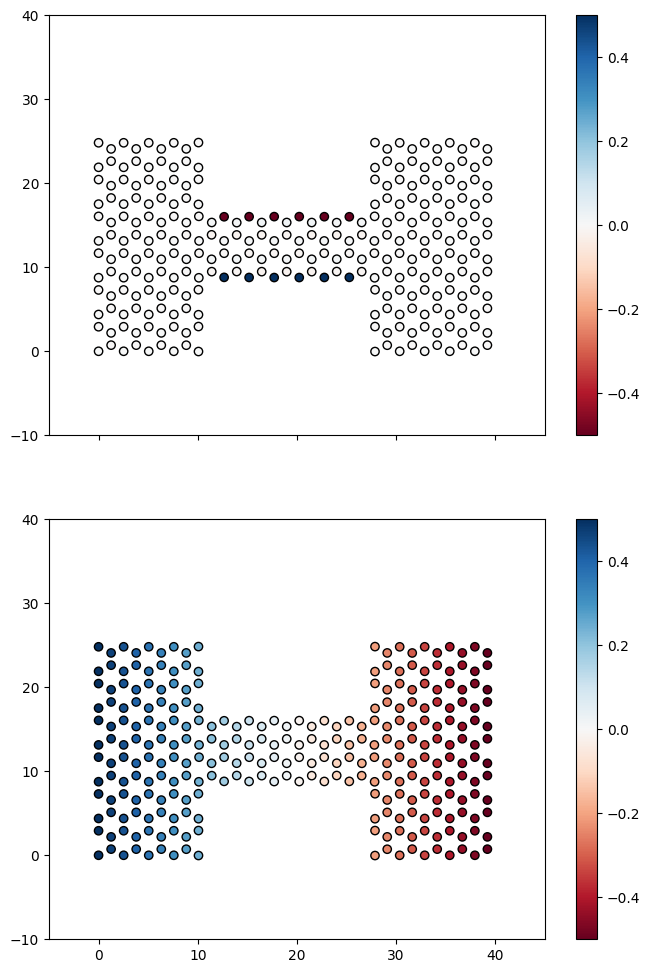

In [48]:
ds=MFH_HC_neq.n[0]-MFH_HC.n[1]
E=MFH_HC_neq.TBHam.tocsr(dim=0).diagonal()

# Create just a figure and only one subplot
fig, ax = plt.subplots(nrows=2,ncols=1,figsize=(8,12),sharex=True)


pcm1=ax[0].scatter(device[:,2],device[:,0],c=ds,cmap='RdBu',vmin=-0.5,vmax=0.5,edgecolors='k')
fig.colorbar(pcm1, ax=ax[0])

ax[0].set_ylim([-10,40])
ax[0].set_xlim([-5,45])


pcm2 = ax[1].scatter(device[:,2],device[:,0],c=E,cmap='RdBu',edgecolors='k')
ax[1].set_ylim([-10,40])
ax[1].set_xlim([-5,45])
fig.colorbar(pcm2, ax=ax[1])

In [49]:
elec_indx = [range(len(H_elec)), range(-len(H_elec), 0)]

# First create the NEGF object, where we pass the MFH converged electrodes and
# the central region HubbardHamiltonian object
negf = NEGF(MFH_HC_neq, [(MFH_elec, '-C'), (MFH_elec, '+C')], elec_indx,V=V,H_eq=MFH_HC)

In [ ]:
MFH_HC_neq.iterate(negf.calc_n_open, **{'qtol':1e-02,'method':'tf'})

In [ ]:
onsite_0=MFH_HC_neq.H.tocsr(dim=0).diagonal()
onsite_1=MFH_HC_neq.H.tocsr(dim=1).diagonal()
onsite=onsite_0
    
    # Create just a figure and only one subplot
fig, ax = plt.subplots(nrows=2,ncols=1,figsize=(8,12),sharex=True)
#fig.suptitle(f'Scf iteration:{i}',size=24)
    
pcm1=ax[0].scatter(device[:,2],device[:,0],c=onsite,cmap='RdBu',vmin=-0.5,vmax=0.5,edgecolors='k')
fig.colorbar(pcm1, ax=ax[0])
    
ax[0].set_ylim([-10,40])
    
ax[0].set_xlim([-5,45])
ax[0].set_ylabel('x Å',size=16)
    
    
ax[1].plot(device[:,2],onsite,c='k')
pcm2=ax[1].scatter(device[:,2],onsite,c=onsite,cmap='RdBu',vmin=-0.5,vmax=0.5,edgecolors='k')
fig.colorbar(pcm2, ax=ax[1])
ax[1].set_ylabel('E (eV)',size=16)
ax[1].set_xlabel('z Å',size=16)

In [ ]:
for i in np.arange(0,15):
    print(f'Scf iteration:{i}')
    onsite_0=MFH_HC_neq.TBHam.tocsr(dim=0).diagonal()
    onsite_1=MFH_HC_neq.TBHam.tocsr(dim=1).diagonal()
    onsite=onsite_0
    
    # Create just a figure and only one subplot
    fig, ax = plt.subplots(nrows=2,ncols=1,figsize=(8,12),sharex=True)
    fig.suptitle(f'Scf iteration:{i}',size=24)
    
    
    pcm1=ax[0].scatter(device[:,2],device[:,0],c=onsite,cmap='RdBu',vmin=-0.5,vmax=0.5,edgecolors='k')
    fig.colorbar(pcm1, ax=ax[0])
    
    ax[0].set_ylim([-10,40])
    
    ax[0].set_xlim([-5,45])
    ax[0].set_ylabel('x Å',size=16)
    
    
    ax[1].plot(device[:,2],onsite,c='k')
    pcm2=ax[1].scatter(device[:,2],onsite,c=onsite,cmap='RdBu',vmin=-0.5,vmax=0.5,edgecolors='k')
    fig.colorbar(pcm2, ax=ax[1])
    ax[1].set_ylabel('E (eV)',size=16)
    ax[1].set_xlabel('z Å',size=16)

    fig.savefig(f'fig_res/fig_{i}')
    plt.clf()
    
    MFH_HC_neq.iterate(negf.calc_n_open, **{'qtol':1e-02,'method':'residual'})

In [73]:
from PIL import Image
import contextlib
import glob
# filepaths
fp_in = "fig_res/fig_*.png"
fp_out = "fig_res/potential.gif"

In [74]:
import imageio
images = []
for i in np.arange(0,50):
    images.append(imageio.imread(f'fig_res/fig_{i}.png'))
imageio.mimsave(fp_out, images,duration=700, loop=0)
del images

/tmp/ipykernel_7909/2889193663.py:4: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  images.append(imageio.imread(f'fig_res/fig_{i}.png'))


# Gating 

## electrodes

In [27]:
sf=1
U=3.5

In [28]:
H0 = sp2(elec_ts, t1=2.7, t2=0.0, t3=0.0, spin='polarized')
q0=H0.q0
print(q0)

48.0


In [29]:
dq=sf*0.25
dn=dq/q0
print(dn,dq)

0.005208333333333333 0.25


In [30]:
# Build sisl.Hamiltonian object using the sp2 function
H_elec = sp2(elec_ts, t1=2.7, t2=0.0, t3=0.0, spin='polarized',dq=dn)
q=H_elec.q0
print(q)

48.24999999999999


In [31]:
# Build the HubbardHamiltonian object with U=3. eV
MFH_elec = HubbardHamiltonian(H_elec, U=U, nkpt=[30,1,30],q=(0.5*q, 0.5*q), kT=0.025)
MFH_elec.random_density()
MFH_elec.converge(density.calc_n, tol=1e-9, print_info=False)    
print('Fermi level of'+str(MFH_elec.fermi_level()))
    
MFH_elec.shift(MFH_elec.fermi_level())

Fermi level of[0.46117237 0.46117237]


Text(0, 0.5, 'E (eV)')

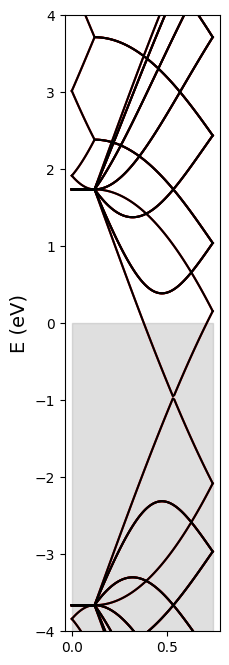

In [75]:
fig, ax = plt.subplots(figsize=(2,8),)
bs = sisl.BandStructure(MFH_elec.H, [ [0.5, 0, 0],[0, 0, 0], [0.0, 0, 0.5]], 100,['X', r'Gamma', 'Z'])
lk = bs.lineark(ticks=False)
bs_eig_0 = bs.apply.array.eigh(spin=0)
bs_eig_1 = bs.apply.array.eigh(spin=1)

ax.plot(lk, bs_eig_0, '-r')
ax.plot(lk, bs_eig_0, '-k')

ax.set_ylim([-4,4])
ax.fill_between(lk, y1=-10, y2=0,color='gray',alpha=0.25)
ax.set_ylabel('E (eV)', size=14)

## Equilibrium

In [76]:
device=device.remove(device.atoms.Z==1)

In [77]:
dQ=(dq)*8
dN=dQ/device.na
print(dN,dQ)

0.007142857142857143 2.0


In [35]:
# Build sisl.Hamiltonian object using the sp2 function
HC= sp2(device, t1=2.7, t2=0.0, t3=0.0, spin='polarized',dq=dN)
# with periodic boundary conditions
HC.set_nsc([3,1,1])

In [37]:
Q=HC.q0
print(Q)

284.0


In [38]:
# MFH object of the central region, same kT and U as electrodes!
MFH_HC = HubbardHamiltonian(HC, U=U, kT=0.025, nkpt=[3,1,1],q=(0.5*Q, 0.5*Q))
# Set initial polarization
MFH_HC.set_polarization([112,120,128,138,147,152], dn=[115,121,129,139,146,155])

# Set electrode indexes
elec_indx = [range(len(H_elec)), range(-len(H_elec), 0)]

# First create the NEGF object, where we pass the MFH converged electrodes and
# the central region HubbardHamiltonian object
negf = NEGF(MFH_HC, [(MFH_elec, '-C'), (MFH_elec, '+C')], elec_indx)

# Converge using Green's function method to obtain the densities
MFH_HC.converge(negf.calc_n_open, steps=5, tol=1e-4, print_info=True)

print('Fermi level of'+str(MFH_elec.fermi_level()))    
MFH_elec.shift(MFH_elec.fermi_level())

   HubbardHamiltonian: converge towards tol=1.00e-04
   5 iterations completed: 0.03513799672740936 -1417.5590697166883
   10 iterations completed: 6.91344562661067e-05 -1417.5003368099801
   found solution in 10 iterations
Fermi level of[-2.63419427e-15 -2.53305764e-15]


In [39]:
DOS_0=MFH_HC.DOS(np.arange(-1,1,0.01),spin=0,)
DOS_1=MFH_HC.DOS(np.arange(-1,1,0.01),spin=1)

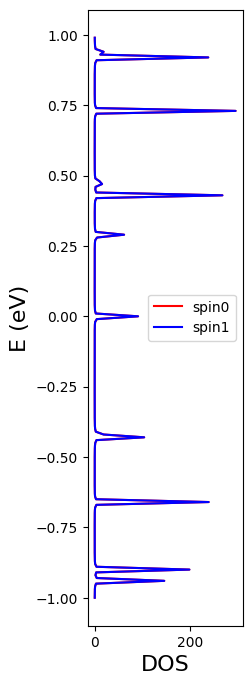

In [40]:
fig, ax = plt.subplots(figsize=(2,8),)

plt.plot(DOS_0,np.arange(-1,1,0.01),label='spin0',c='r')
plt.plot(DOS_1,np.arange(-1,1,0.01),label='spin1',c='b')
plt.ylabel('E (eV)',size=16)
plt.xlabel('DOS',size=16)
plt.legend()

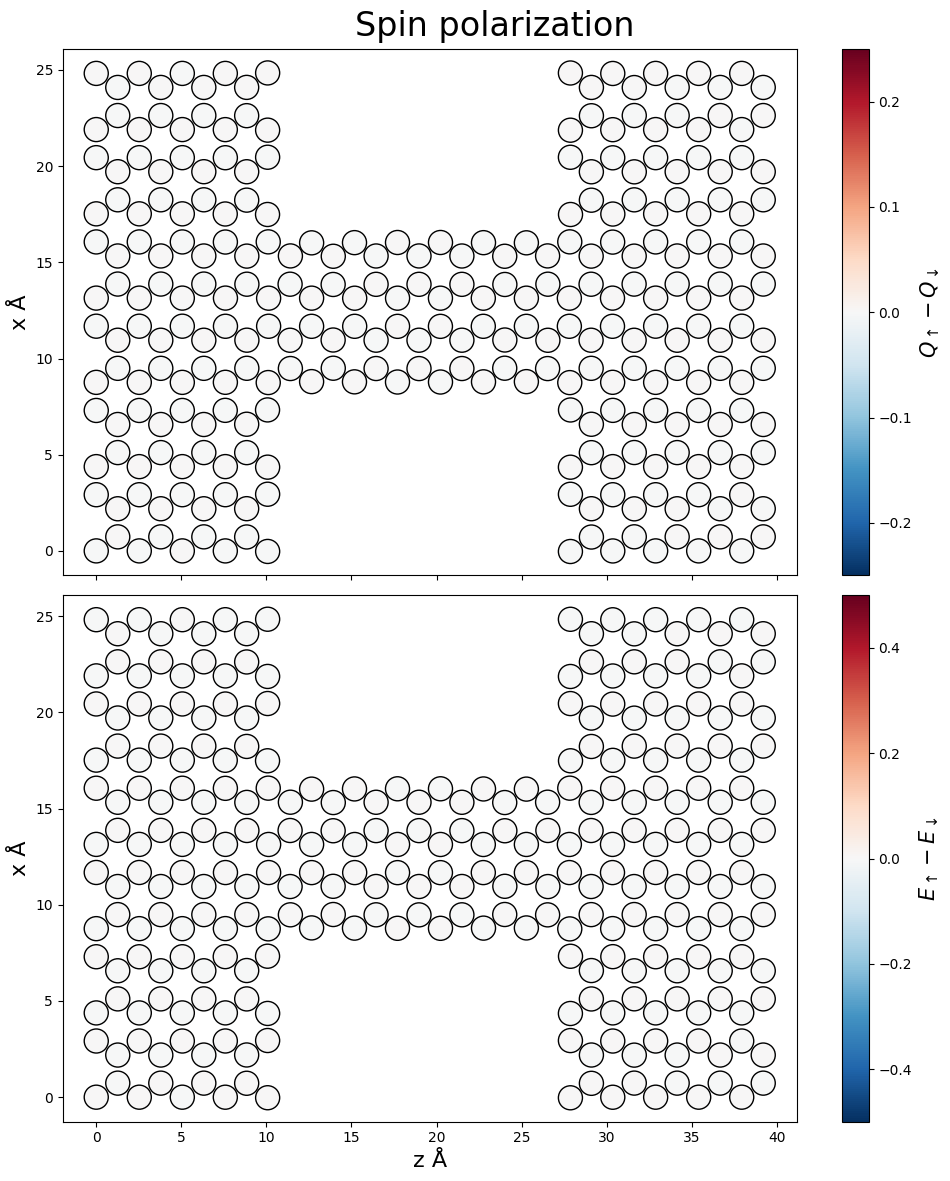

In [41]:
ds=MFH_HC.n[0]-MFH_HC.n[1]
dE=MFH_HC.H.tocsr(dim=0).diagonal()-MFH_HC.H.tocsr(dim=1).diagonal()

# Create just a figure and only one subplot
fig, ax = plt.subplots(nrows=2,ncols=1,figsize=(10,12),sharex=True)
fig.suptitle(f'Spin polarization',size=24)


pcm1=ax[0].scatter(device[:,2],device[:,0],c=ds,cmap='RdBu_r',vmin=-0.25,vmax=0.25,edgecolors='k',s=300)
fig.colorbar(pcm1, ax=ax[0],).set_label(label=r'${Q_\uparrow}-{Q_\downarrow}$',size=15,weight='bold')

ax[0].set_ylabel('x Å',size=16)

bonds=False
if bonds==True:
    for i in range(len((device.xyz))):
        for j in range(i + 1, len((device.xyz))):
            dist_3d = np.linalg.norm((device.xyz[i] - (device.xyz[j])))
            if dist_3d < 1.77:
                x_vals = [device.xyz[i][2], device.xyz[j][2]]
                z_vals = [device.xyz[i][0], device.xyz[j][0]]
                ax[0].plot(x_vals, z_vals, color='gray', linewidth=1)
            
for i, txt in enumerate(ds):
    if np.abs(txt)>0.05:
        ax[0].annotate(np.round(txt,2), (device.xyz[i,2]-1.8, device.xyz[i,0]),size=10)


pcm2 = ax[1].scatter(device[:,2],device[:,0],c=dE,cmap='RdBu_r',vmin=-0.5,vmax=0.5,edgecolors='k',s=300)
fig.colorbar(pcm2, ax=ax[1]).set_label(label=r'${E_\uparrow}-{E_\downarrow}$',size=15,weight='bold')
ax[1].set_ylabel('x Å',size=16)
ax[1].set_xlabel('z Å',size=16)
fig.tight_layout()
plt.show()

## Non Equilibrium*

In [45]:
V=1

In [46]:
# Build sisl.Hamiltonian object using the sp2 function
HC= sp2(device, t1=2.7, t2=0.0, t3=0.0, spin='polarized',q=(0.5*Q, 0.5*Q))
# with periodic boundary conditions
HC.set_nsc([3,1,1])

In [49]:
init_V(HC,V=V,elec_indx=elec_indx,axis=2)

In [51]:
onsite_0=HC.H.tocsr(dim=0).diagonal()
onsite_1=HC.H.tocsr(dim=1).diagonal()

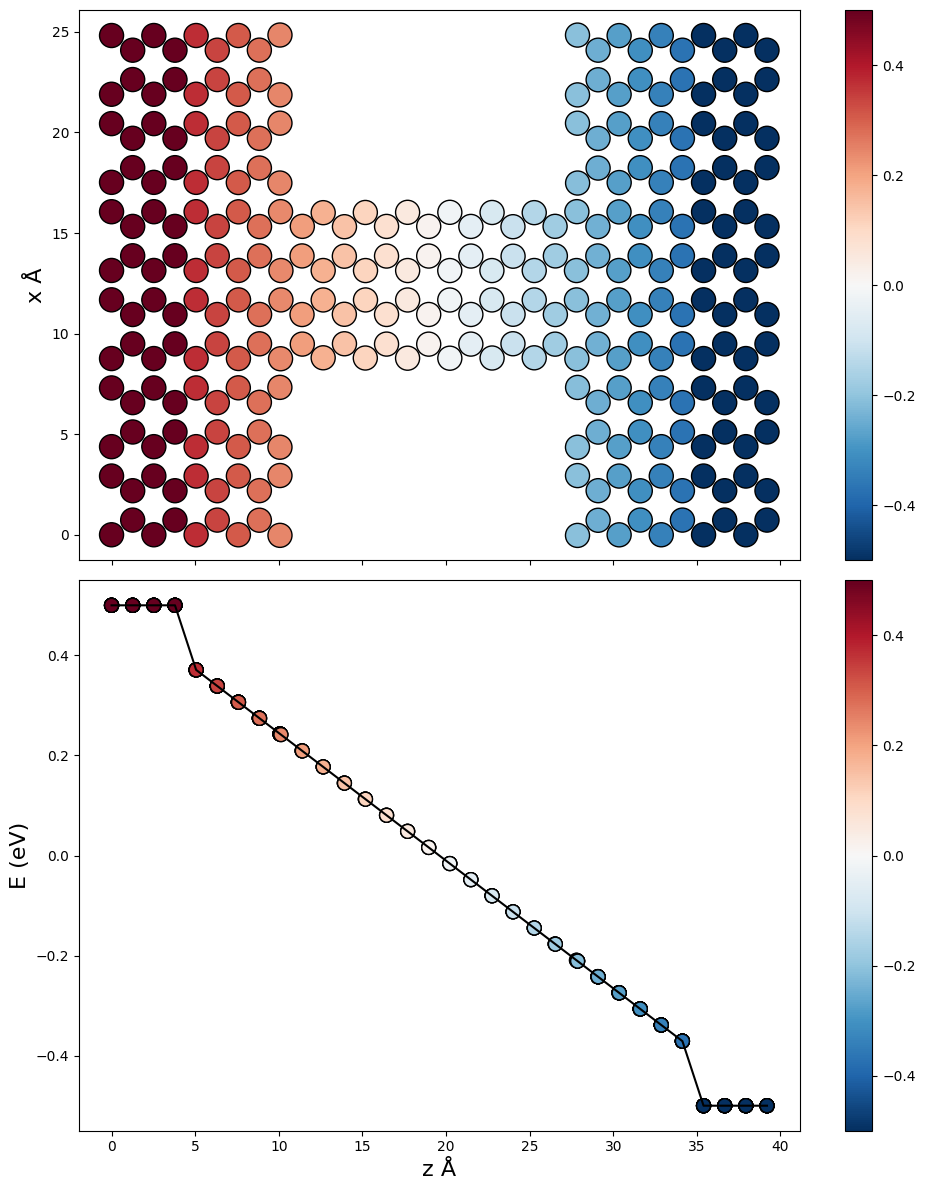

In [68]:
onsite=onsite_0
# Create just a figure and only one subplot
fig, ax = plt.subplots(nrows=2,ncols=1,figsize=(10,12),sharex=True)


pcm1=ax[0].scatter(device[:,2],device[:,0],c=onsite,cmap='RdBu_r',vmin=-0.5*V,vmax=0.5,edgecolors='k',s=300)
fig.colorbar(pcm1, ax=ax[0])


ax[0].set_ylabel('x Å',size=16)
ax[1].plot(device[:,2],onsite,c='k')
pcm2=ax[1].scatter(device[:,2],onsite,c=onsite,cmap='RdBu_r',vmin=-0.5*V,vmax=0.5*V,edgecolors='k',s=100)
fig.colorbar(pcm2, ax=ax[1])
ax[1].set_ylabel('E (eV)',size=16)
ax[1].set_xlabel('z Å',size=16)
fig.tight_layout()

In [60]:
MFH_HC_neq = HubbardHamiltonian(HC, U=U, kT=0.025,nkpt=[1,1,1])

In [61]:
MFH_HC_neq.set_polarization([112,120,128,138,147,152], dn=[115,121,129,139,146,155])

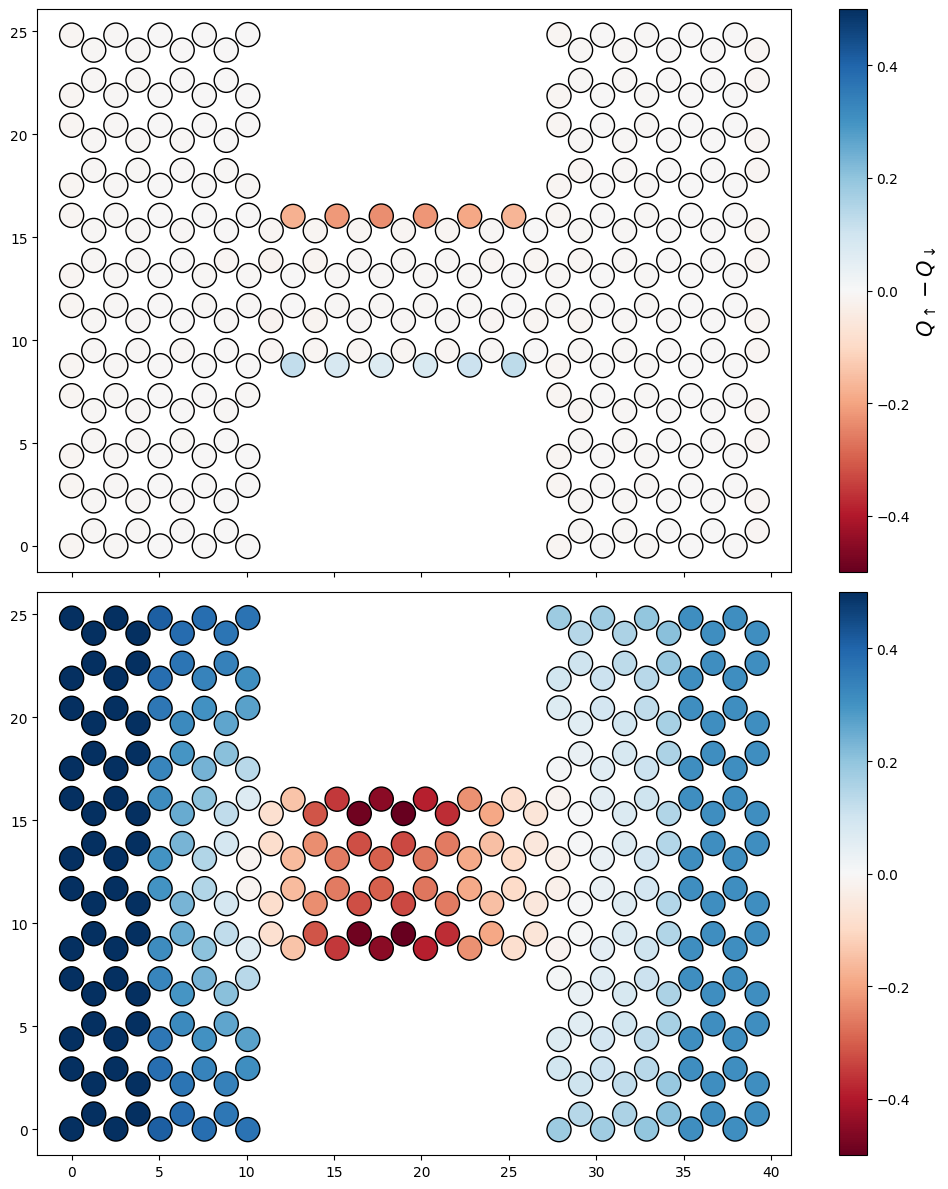

In [73]:
ds=MFH_HC_neq.n[0]-MFH_HC.n[1]
dE=MFH_HC.H.tocsr(dim=0).diagonal()-MFH_HC.H.tocsr(dim=1).diagonal()

# Create just a figure and only one subplot
fig, ax = plt.subplots(nrows=2,ncols=1,figsize=(10,12),sharex=True)


pcm1=ax[0].scatter(device[:,2],device[:,0],c=ds,cmap='RdBu',vmin=-0.5,vmax=0.5,edgecolors='k',s=300)
fig.colorbar(pcm1, ax=ax[0],).set_label(label=r'${Q_\uparrow}-{Q_\downarrow}$',size=15)

pcm2 = ax[1].scatter(device[:,2],device[:,0],c=E,cmap='RdBu',edgecolors='k',s=300)
fig.colorbar(pcm1, ax=ax[1],)
fig.tight_layout()

In [69]:
elec_indx = [range(len(H_elec)), range(-len(H_elec), 0)]

# First create the NEGF object, where we pass the MFH converged electrodes and
# the central region HubbardHamiltonian object
negf = NEGF(MFH_HC_neq, [(MFH_elec, '-C'), (MFH_elec, '+C')], elec_indx,V=V,H_eq=MFH_HC)

In [70]:
MFH_HC_neq.iterate(negf.calc_n_open, **{'qtol':1e-02,'method':'tf'})

np.float64(0.5194200367386057)

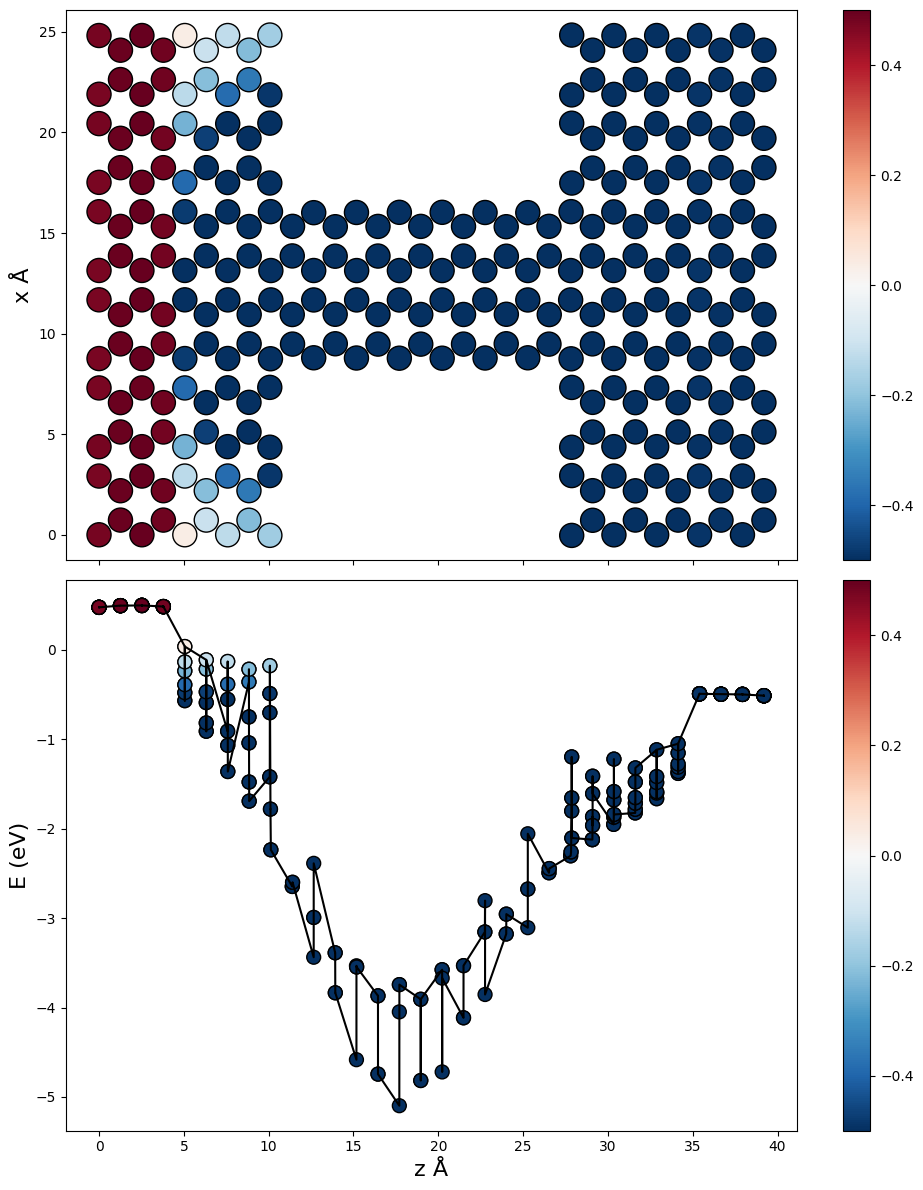

In [71]:
onsite_0=MFH_HC_neq.H.tocsr(dim=0).diagonal()
onsite_1=MFH_HC_neq.H.tocsr(dim=1).diagonal()
onsite=onsite_0


# Create just a figure and only one subplot
fig, ax = plt.subplots(nrows=2,ncols=1,figsize=(10,12),sharex=True)


pcm1=ax[0].scatter(device[:,2],device[:,0],c=onsite,cmap='RdBu_r',vmin=-0.5*V,vmax=0.5,edgecolors='k',s=300)
fig.colorbar(pcm1, ax=ax[0])


ax[0].set_ylabel('x Å',size=16)
ax[1].plot(device[:,2],onsite,c='k')
pcm2=ax[1].scatter(device[:,2],onsite,c=onsite,cmap='RdBu_r',vmin=-0.5*V,vmax=0.5*V,edgecolors='k',s=100)
fig.colorbar(pcm2, ax=ax[1])
ax[1].set_ylabel('E (eV)',size=16)
ax[1].set_xlabel('z Å',size=16)
fig.tight_layout()